In [2]:
!mkdir eurosat_project
!mkdir eurosat_project/data
!mkdir eurosat_project/notebooks
!mkdir eurosat_project/src
!mkdir eurosat_project/outputs
!mkdir eurosat_project/outputs/checkpoints
!mkdir eurosat_project/outputs/plots

In [2]:
#steps 0 - installing libraries
!pip install torch torchvision torchaudio pandas numpy matplotlib seaborn scikit-learn pillow kaggle jupyter scipy

In [4]:
# step 1 - importing libraries

import os
import urllib.request
import zipfile
from pathlib import Path
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

print("Setup successful")
print("Torch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)

Setup successful
Torch version: 2.11.0
Torchvision version: 0.26.0


In [5]:
# Step 2 — Project Paths

BASE_DIR = Path.cwd()

DATA_DIR = BASE_DIR / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"

RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print("Project structure ready")

Project structure ready


In [6]:
# Step 3 — Download Dataset

url = "https://madm.dfki.de/files/sentinel/EuroSAT.zip"
zip_path = RAW_DIR / "EuroSAT.zip"

if not zip_path.exists():
    print("Downloading dataset...")
    urllib.request.urlretrieve(url, zip_path)
    print("Download complete")
else:
    print("Dataset already exists")

Dataset already exists


In [7]:
# Step 4 — Extract Dataset

extract_path = RAW_DIR

extracted_folder = RAW_DIR / "2750"

if not extracted_folder.exists():
    print("Extracting dataset...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Extraction complete")
else:
    print("Dataset already extracted")

Dataset already extracted


In [8]:
# Step 5 — Load Dataset Path

data_dir = RAW_DIR / "2750"

# Check folders
classes = [folder.name for folder in data_dir.iterdir() if folder.is_dir()]

print("Classes:")
print(classes)

print("\nNumber of classes:", len(classes))

Classes:
['Forest', 'River', 'Highway', 'AnnualCrop', 'SeaLake', 'HerbaceousVegetation', 'Industrial', 'Residential', 'PermanentCrop', 'Pasture']

Number of classes: 10


In [9]:
# Step 6 - Class mapping 

class_map = {
    "AnnualCrop": "annual_crop",
    "Forest": "forest",
    "HerbaceousVegetation": "herbaceous_vegetation",
    "Highway": "highway",
    "Industrial": "industrial",
    "Pasture": "pasture",
    "PermanentCrop": "permanent_crop",
    "Residential": "residential",
    "River": "river",
    "SeaLake": "sea_lake"
}

class_map

{'AnnualCrop': 'annual_crop',
 'Forest': 'forest',
 'HerbaceousVegetation': 'herbaceous_vegetation',
 'Highway': 'highway',
 'Industrial': 'industrial',
 'Pasture': 'pasture',
 'PermanentCrop': 'permanent_crop',
 'Residential': 'residential',
 'River': 'river',
 'SeaLake': 'sea_lake'}

In [26]:
# Step 7 — Build Dataset (Image Paths & Labels)

from pathlib import Path

data_dir = RAW_DIR / "2750"

/Users/ehsankhajehamiri/AI for space


In [11]:
image_paths = []
labels = []

for folder in data_dir.iterdir():
    if folder.is_dir():
        original_class = folder.name

        mapped_class = class_map[original_class]
        
        for img_file in folder.glob("*"):
            image_paths.append(str(img_file))
            labels.append(mapped_class)

print("Total images:", len(image_paths))
print("Total labels:", len(labels))

Total images: 27000
Total labels: 27000


In [12]:
# Step 8 — Dataset Inspection

for i in range(10):
    print(labels[i])

forest
forest
forest
forest
forest
forest
forest
forest
forest
forest


In [13]:
from collections import Counter

Counter(labels)

Counter({'forest': 3000,
         'annual_crop': 3000,
         'sea_lake': 3000,
         'herbaceous_vegetation': 3000,
         'residential': 3000,
         'river': 2500,
         'highway': 2500,
         'industrial': 2500,
         'permanent_crop': 2500,
         'pasture': 2000})

In [14]:
# Step 9 — Label Encoding

label_to_idx = {label: idx for idx, label in enumerate(sorted(set(labels)))}

numeric_labels = [label_to_idx[label] for label in labels]

print(label_to_idx)

{'annual_crop': 0, 'forest': 1, 'herbaceous_vegetation': 2, 'highway': 3, 'industrial': 4, 'pasture': 5, 'permanent_crop': 6, 'residential': 7, 'river': 8, 'sea_lake': 9}


In [15]:
print(len(image_paths), len(numeric_labels))

27000 27000


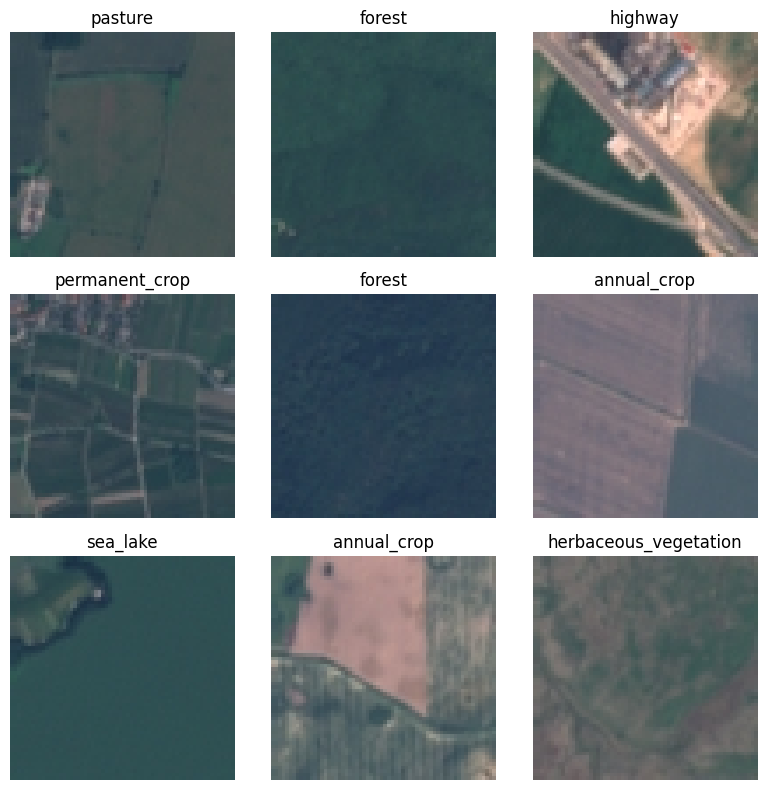

In [16]:
# Step 10 — Visualize Raw Images

from PIL import Image
import matplotlib.pyplot as plt
import random

num_images = 9

plt.figure(figsize=(8, 8))

for i in range(num_images):
    idx = random.randint(0, len(image_paths)-1)
    
    img = Image.open(image_paths[idx])
    label = labels[idx]
    
    plt.subplot(3, 3, i+1)
    plt.imshow(img)
    plt.title(label)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [17]:
# Step 11 — Train / Validation / Test Split

from sklearn.model_selection import train_test_split
from collections import Counter

X_train, X_temp, y_train, y_temp = train_test_split(
    image_paths,
    numeric_labels,
    test_size=0.3,
    random_state=42,
    stratify=numeric_labels
)

In [18]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

In [19]:
print("Train:", len(X_train))
print("Validation:", len(X_val))
print("Test:", len(X_test))

print("Train:", Counter(y_train))
print("Validation:", Counter(y_val))
print("Test:", Counter(y_test))

Train: 18900
Validation: 4050
Test: 4050
Train: Counter({7: 2100, 9: 2100, 0: 2100, 1: 2100, 2: 2100, 6: 1750, 4: 1750, 3: 1750, 8: 1750, 5: 1400})
Validation: Counter({9: 450, 2: 450, 1: 450, 0: 450, 7: 450, 3: 375, 4: 375, 6: 375, 8: 375, 5: 300})
Test: Counter({9: 450, 0: 450, 7: 450, 1: 450, 2: 450, 6: 375, 4: 375, 3: 375, 8: 375, 5: 300})


In [20]:
#Step 12 — Custom Dataset Class

import torch
from torch.utils.data import Dataset
from PIL import Image

class EuroSATDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert("RGB")

        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

In [21]:
# Step 13 — Data Transforms

from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [22]:
# Step 14 — Create Dataset Objects

train_dataset = EuroSATDataset(X_train, y_train, transform=train_transform)
val_dataset   = EuroSATDataset(X_val, y_val, transform=val_test_transform)
test_dataset  = EuroSATDataset(X_test, y_test, transform=val_test_transform)

In [23]:
img, label = train_dataset[0]

print(img.shape)
print(label)

torch.Size([3, 64, 64])
7


In [24]:
# Step 15 — DataLoaders

from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([64, 3, 64, 64])
torch.Size([64])


Before: -2.1179039478302 0.8622223734855652
After: 0.0 0.6000000238418579


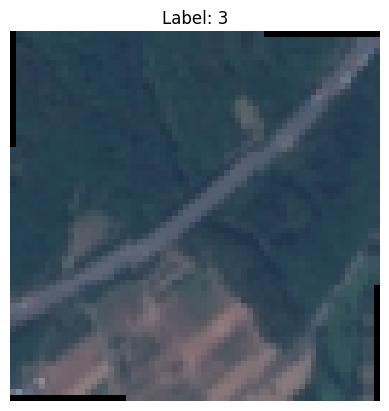

In [25]:
#Step 16 — Final Visualization

import random
import matplotlib.pyplot as plt

images, labels = next(iter(train_loader))

idx = random.randint(0, len(images)-1)
img = images[idx]
label = labels[idx]

print("Before:", img.min().item(), img.max().item())

mean = torch.tensor([0.485, 0.456, 0.406])
std = torch.tensor([0.229, 0.224, 0.225])

img = img * std[:, None, None] + mean[:, None, None]

print("After:", img.min().item(), img.max().item())

# convert
img_np = img.permute(1, 2, 0).numpy()
img_np = img_np.clip(0, 1)

# show
plt.imshow(img_np)
plt.title(f"Label: {label.item()}")
plt.axis("off")
plt.show()